In [1]:
# Types of supervised learning
# classification -> categorical response
# regression -> continuous response

In [4]:
# Reading data using pandas
import pandas as pd

df = pd.read_csv('data/Advertising.csv', index_col = 0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [5]:
# display last 5 rows
df.tail()

,TV,Radio,Newspaper,Sales
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,8.6,8.7,13.4


In [8]:
# check the shape of DF (rows, columns)
df.shape
# features -> columns
# observations -> rows

(200, 4)

In [9]:
# data analysis
# an observation contain a advertising dollar spent on a single market and Sales is the count of sales in thousands
# data is continuous and hence it's a regression problem

In [11]:
# data visualization using seaborn (built on top of matplotlib)
import seaborn as sns

%matplotlib inline

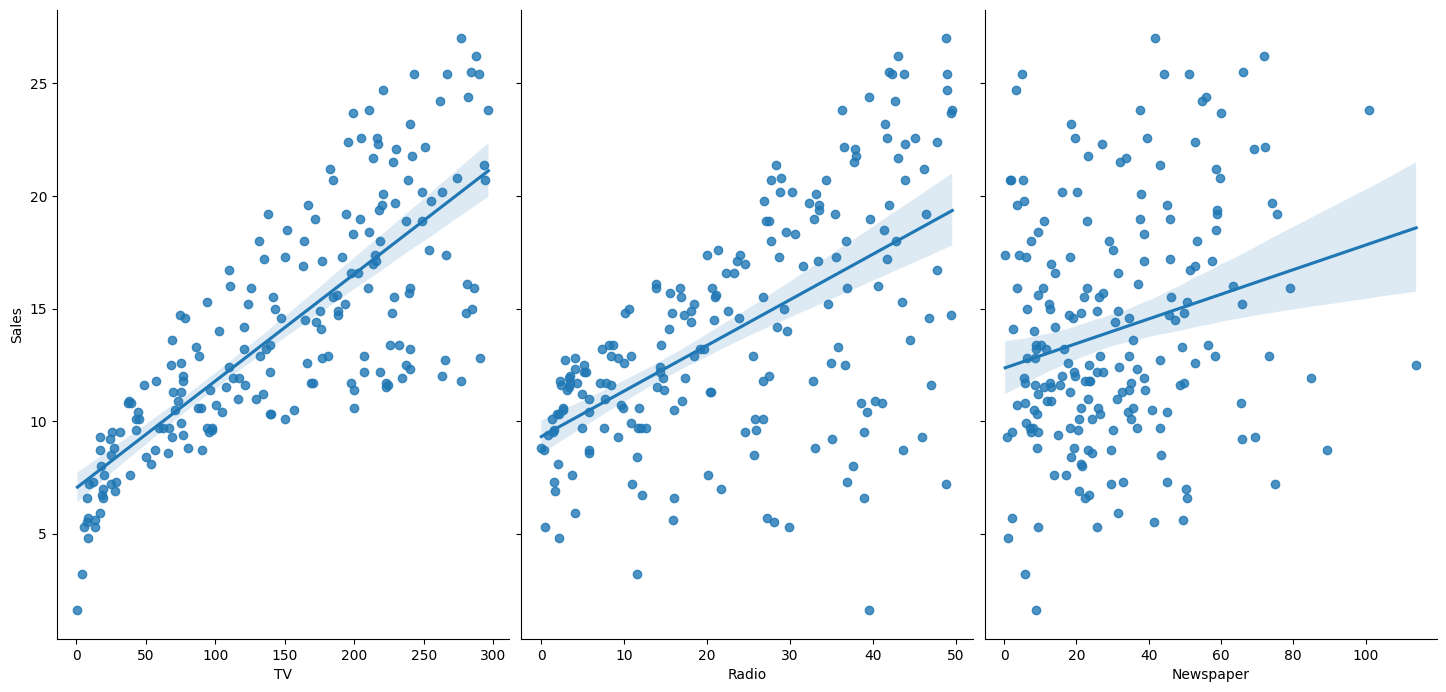

In [15]:
# visualize response using scatterplot
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height = 7, aspect=0.7, kind='reg')

In [ ]:
# Linear regression
# Prepare X (feature matrix) and y (response vector) should be numpy arrays
# Pandas is built on top of numpy
# X can be pandas dataframe and y can be pandas series

In [17]:
feature_cols = ['TV', 'Radio', 'Newspaper']

X = df[feature_cols]

# Inline equivalent
X1 = df[['TV', 'Radio', 'Newspaper']]

X.head()

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4


In [20]:
print(type(X))
X.shape

<class 'pandas.core.frame.DataFrame'>


(200, 3)

In [23]:
y = df['Sales']

# equivalent if feature column doesn't have spaces
y1 = df.Sales

y.head()

1    22.1
2    10.4
3     9.3
4    18.5
5    12.9
Name: Sales, dtype: float64

In [24]:
print(type(y))
y.shape

<class 'pandas.core.series.Series'>


(200,)

In [31]:
# Split the dataset into train and test dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [32]:
# by default it splits to 75% for training and 25% for test dataset
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(150, 3)
(150,)
(50, 3)
(50,)


In [34]:
# Linear regression in scikit learn
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

LinearRegression()

In [35]:
# print intercept and coefficients
print(linreg.intercept_)
print(linreg.coef_)

2.87696662231793
[0.04656457 0.17915812 0.00345046]


In [36]:
# Associate coefficients with features
list(zip(feature_cols, linreg.coef_))

[('TV', np.float64(0.04656456787415026)),
 ('Radio', np.float64(0.17915812245088852)),
 ('Newspaper', np.float64(0.0034504647111804326))]

In [49]:
# prediction
y_pred = linreg.predict(X_test)
print(y_pred)

[21.70910292 16.41055243  7.60955058 17.80769552 18.6146359  23.83573998
 16.32488681 13.43225536  9.17173403 17.333853   14.44479482  9.83511973
 17.18797614 16.73086831 15.05529391 15.61434433 12.42541574 17.17716376
 11.08827566 18.00537501  9.28438889 12.98458458  8.79950614 10.42382499
 11.3846456  14.98082512  9.78853268 19.39643187 18.18099936 17.12807566
 21.54670213 14.69809481 16.24641438 12.32114579 19.92422501 15.32498602
 13.88726522 10.03162255 20.93105915  7.44936831  3.64695761  7.22020178
  5.9962782  18.43381853  8.39408045 14.08371047 15.02195699 20.35836418
 20.57036347 19.60636679]


In [39]:
# Calculate evaluation metrics to compare prediction with actual values
# Accuracy metric used for classification won't work for regression

In [42]:
# Model evaluation metrics for regression

true=[100, 50, 20, 80]
pred=[80, 50, 30, 70]

# 1. Mean Absolute Error (MAE)
print(((100-80) + (50-50) + (abs(20-30)) + (80-70))/4)

from sklearn import metrics
print(metrics.mean_absolute_error(true, pred))

10.0
10.0


In [44]:
# 2. Mean Squared Error (MSE)
print((pow(100-80, 2) + pow(50-50, 2) + pow(abs(20-30), 2) + pow(80-70, 2))/4)

print(metrics.mean_squared_error(true, pred))

150.0
150.0


In [47]:
# Root Mean Squared Error
import numpy as np
print(np.sqrt((pow(100-80, 2) + pow(50-50, 2) + pow(abs(20-30), 2) + pow(80-70, 2))/4))

print(np.sqrt(metrics.mean_squared_error(true, pred)))

12.24744871391589
12.24744871391589


In [48]:
# Compute RMSE for sales prediction
print(metrics.root_mean_squared_error(y_test, y_pred))

1.4046514230328946


In [52]:
# Feature selection
# Does Newspaper belong in our model? does it improve quality of predictions?
new_feature_cols = ['TV', 'Radio']

new_X = df[new_feature_cols]
new_y = df.Sales

# split dataset into train/test
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, new_y, random_state = 1)

linreg = LinearRegression()
linreg.fit(new_X_train, new_y_train)

new_y_pred = linreg.predict(new_X_test)

print(metrics.root_mean_squared_error(new_y_test, new_y_pred))

1.387903469938288


In [53]:
# RMSE decreased -> Hence Newspaper feature can be dropped